# Method 5 — Multi-Outcome SCM

**Logic:** If the treatment caused a real shift in rail volumes, related outcomes should move consistently. We re-fit SCM independently for each outcome (`Rail_Vol_mt`, `Market_Share_Pct`, `Road_Vol_Est_mt`, `Avg_Delay_Hrs`) and compare RMSPE ratios.

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def fit_scm(Y_pre, X_pre):
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Y_pre - X_pre @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.SCS)
    return np.array(w.value).flatten()

def rmspe(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))


## Data Preparation

In [2]:
df = pd.read_csv('./data/corridor.csv')
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

treated     = 'NATCOR'
treat_start = pd.Period('2022-04', freq='M')
pre_end     = treat_start - 1

# We need a period index from any outcome — use Rail_Vol_mt for indexing
_wide_ref = df.pivot(index='Date_period', columns='Corridor', values='Rail_Vol_mt').sort_index()
pre_idx   = _wide_ref.index[_wide_ref.index <= pre_end]
post_idx  = _wide_ref.index[_wide_ref.index >= treat_start]
treat_t   = treat_start.to_timestamp()

print(f'Pre periods : {len(pre_idx)} ({pre_idx[0]} – {pre_idx[-1]})')
print(f'Post periods: {len(post_idx)} ({post_idx[0]} – {post_idx[-1]})')

# Outcomes to analyse
outcomes = {
    'Rail_Vol_mt'     : 'Rail Volume (MT)',
    'Market_Share_Pct': 'Market Share (%)',
    'Road_Vol_Est_mt' : 'Road Volume Estimate (MT)',
    'Avg_Delay_Hrs'   : 'Avg Delay (Hrs)',
}
print(f'Outcomes    : {list(outcomes.keys())}')


Pre periods : 87 (2015-01 – 2022-03)
Post periods: 33 (2022-04 – 2024-12)
Outcomes    : ['Rail_Vol_mt', 'Market_Share_Pct', 'Road_Vol_Est_mt', 'Avg_Delay_Hrs']


## Multi-Outcome SCM Estimation & Figure 5

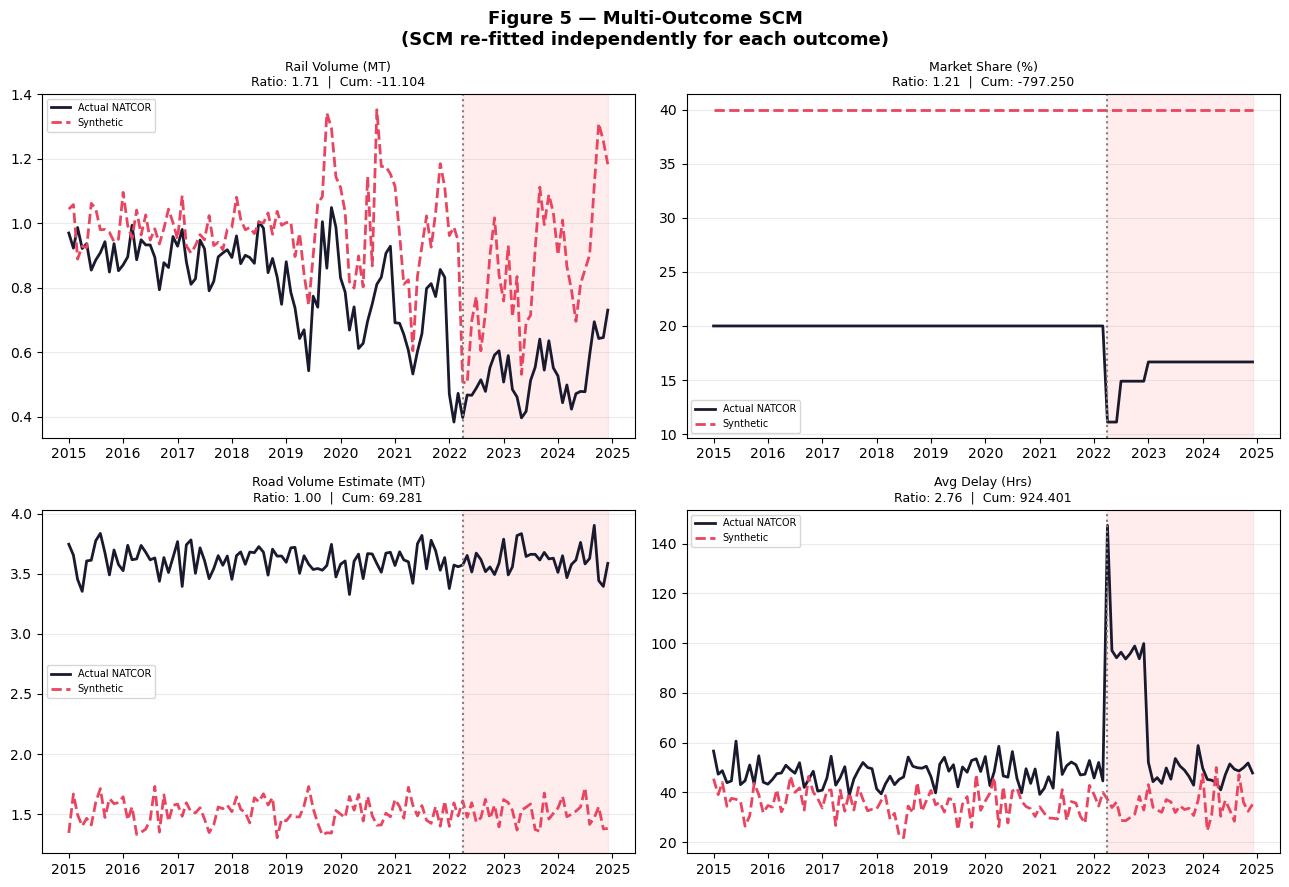

Figure saved → fig5_multi_outcome_scm.png


In [3]:
# ── Method 5 : Multi-Outcome SCM ──────────────────────────────────────────────
# Logic: Re-fit SCM independently for each outcome.
# If treatment caused a real shift, related outcomes should move consistently.
# Converging ratios > 1 across outcomes strengthen the causal interpretation.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Figure 5 — Multi-Outcome SCM\n'
    '(SCM re-fitted independently for each outcome)',
    fontsize=13, fontweight='bold')

multi_summary = []
for (col, label), ax in zip(outcomes.items(), axes.flatten()):
    w_out  = df.pivot(index='Date_period', columns='Corridor', values=col).sort_index()
    d_out  = [c for c in w_out.columns if c != treated]

    w_o    = fit_scm(w_out.loc[pre_idx, treated].values,
                     w_out.loc[pre_idx, d_out].values)
    sy_o   = pd.Series(w_out[d_out].values @ w_o, index=w_out.index)
    act_o  = w_out[treated]
    gap_o  = act_o - sy_o
    pre_r  = rmspe(act_o[pre_idx], sy_o[pre_idx])
    post_r = rmspe(act_o[post_idx], sy_o[post_idx])
    ratio_o = post_r / pre_r
    cum_o  = gap_o[post_idx].sum()

    multi_summary.append({
        'Outcome': col,
        'Label': label,
        'Pre-RMSPE': round(pre_r, 4),
        'Post-RMSPE': round(post_r, 4),
        'Ratio': round(ratio_o, 3),
        'Cum Effect': round(cum_o, 4),
        'Ratio > 1': ratio_o > 1,
    })

    t_out = w_out.index.to_timestamp()
    ax.plot(t_out, act_o.values, color='#1a1a2e', lw=2, label='Actual NATCOR')
    ax.plot(t_out, sy_o.values,  color='#e94560', lw=2, ls='--', label='Synthetic')
    ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
    ax.axvspan(treat_t, t_out[-1], alpha=0.07, color='red')
    ax.set_title(f'{label}\nRatio: {ratio_o:.2f}  |  Cum: {cum_o:.3f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('fig5_multi_outcome_scm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fig5_multi_outcome_scm.png')


## Summary Table

In [4]:
# ── Summary table ─────────────────────────────────────────────────────────────
result_df = pd.DataFrame(multi_summary)
print(result_df[['Outcome', 'Pre-RMSPE', 'Post-RMSPE', 'Ratio', 'Cum Effect', 'Ratio > 1']].to_string(index=False))

n_above = sum(r > 1 for r in result_df['Ratio'])
print(f'\nOutcomes with Ratio > 1 : {n_above} / {len(result_df)}')
print('Interpretation: Multiple outcomes with Ratio > 1 supports that the treatment')
print('had a consistent real effect beyond noise, not confined to rail volume alone.')
result_df[['Outcome', 'Label', 'Pre-RMSPE', 'Post-RMSPE', 'Ratio', 'Cum Effect', 'Ratio > 1']]


         Outcome  Pre-RMSPE  Post-RMSPE  Ratio  Cum Effect  Ratio > 1
     Rail_Vol_mt     0.2132      0.3653  1.714    -11.1040       True
Market_Share_Pct    20.0000     24.2149  1.211   -797.2500       True
 Road_Vol_Est_mt     2.0995      2.1048  1.003     69.2810       True
   Avg_Delay_Hrs    14.0629     38.7732  2.757    924.4005       True

Outcomes with Ratio > 1 : 4 / 4
Interpretation: Multiple outcomes with Ratio > 1 supports that the treatment
had a consistent real effect beyond noise, not confined to rail volume alone.


,Outcome,Label,Pre-RMSPE,Post-RMSPE,Ratio,Cum Effect,Ratio > 1
0,Rail_Vol_mt,Rail Volume (MT),0.2132,0.3653,1.714,-11.1040,True
1,Market_Share_Pct,Market Share (%),20.0000,24.2149,1.211,-797.2500,True
2,Road_Vol_Est_mt,Road Volume Estimate (MT),2.0995,2.1048,1.003,69.2810,True
3,Avg_Delay_Hrs,Avg Delay (Hrs),14.0629,38.7732,2.757,924.4005,True


## Figure 5b — Gap Plots per Outcome (Optional)

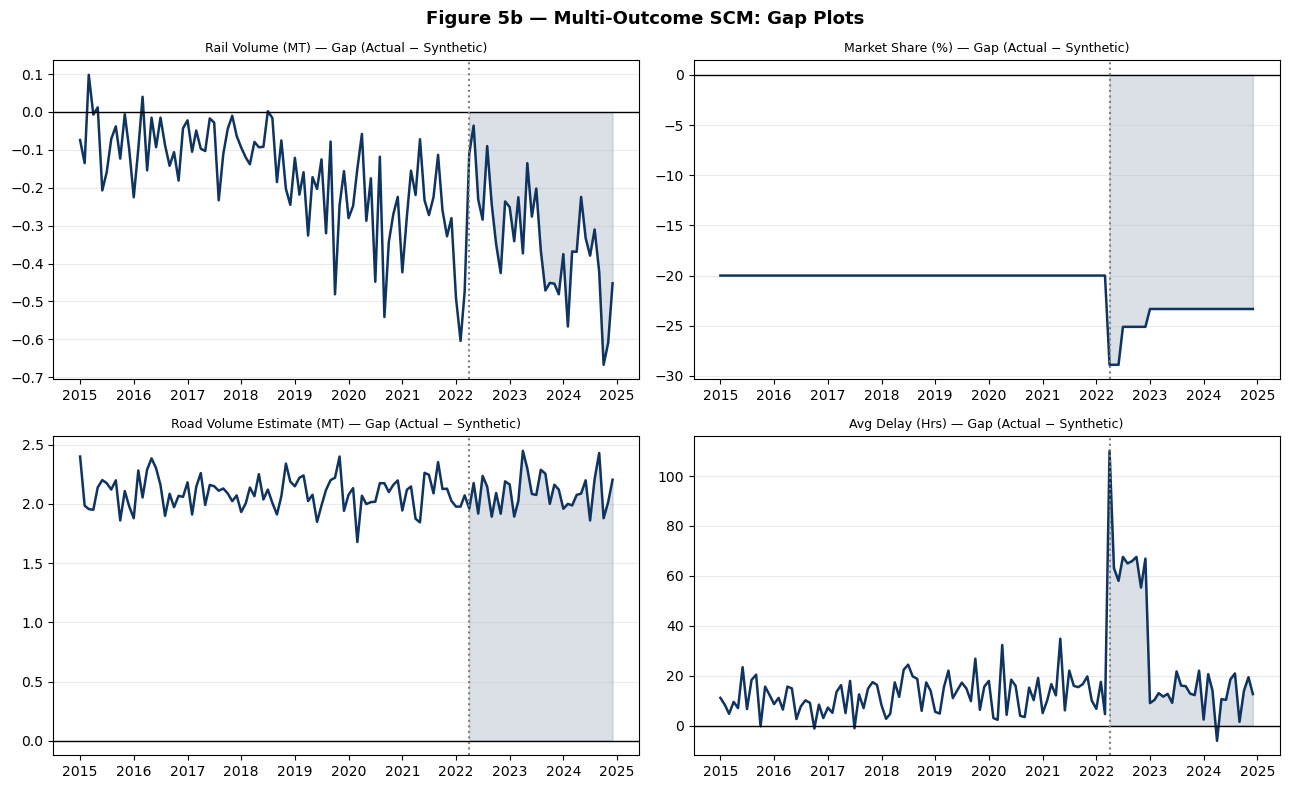

Figure saved → fig5b_multi_outcome_gaps.png


In [5]:
# ── Optional: Gap plots per outcome ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Figure 5b — Multi-Outcome SCM: Gap Plots', fontsize=13, fontweight='bold')

for (col, label), ax in zip(outcomes.items(), axes.flatten()):
    w_out  = df.pivot(index='Date_period', columns='Corridor', values=col).sort_index()
    d_out  = [c for c in w_out.columns if c != treated]
    w_o    = fit_scm(w_out.loc[pre_idx, treated].values, w_out.loc[pre_idx, d_out].values)
    sy_o   = pd.Series(w_out[d_out].values @ w_o, index=w_out.index)
    gap_o  = w_out[treated] - sy_o
    t_out  = w_out.index.to_timestamp()

    ax.plot(t_out, gap_o.values, color='#0f3460', lw=1.8)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
    ax.fill_between(t_out, gap_o.values, 0, where=(w_out.index >= treat_start),
                    alpha=0.15, color='#0f3460')
    ax.set_title(f'{label} — Gap (Actual − Synthetic)', fontsize=9)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('fig5b_multi_outcome_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fig5b_multi_outcome_gaps.png')
